In [4]:
## problem 1 Flowchart
def Print_values(a, b, c):
    """Follow the flowchart, choose [x,y,z], then print x + y - 10*z."""
    if a > b:                       # a > b ?
        if b > c:                   # b > c ?
            x, y, z = a, b, c       # a, b, c
        else:                       # b <= c
            if a > c:               # a > c ?
                x, y, z = a, c, b   # a, c, b
            else:
                x, y, z = c, a, b   # c, a, b
    else:                           # a <= b
        if b > c:                   # b > c ?
            if a > c:               # a > c ?
                x, y, z = a, c, b   # b, a, c
            else:
                x, y, z = c, a, b   # b, c, a
        else:
            x, y, z = c, b, a       # c, b, a

    val = x + y - 10 * z
    print(f"[x, y, z] = [{x}, {y}, {z}]  ->  x + y - 10z = {val}")
    return val
# 随便试两组
Print_values(7, 2, 9)
Print_values(3, 5, 1)

# 题目要求：a=5, b=15, c=10
Print_values(5, 15, 10)

[x, y, z] = [9, 7, 2]  ->  x + y - 10z = -4
[x, y, z] = [3, 1, 5]  ->  x + y - 10z = -46
[x, y, z] = [10, 5, 15]  ->  x + y - 10z = -135


-135

In [5]:
## problem 2 Continuous ceiling function
from math import ceil

def Fx(x):
    if not isinstance(x, int) or x < 1:
        raise ValueError("x must be a positive integer")
    val = 1
    y = x
    while y > 1:
        val = val + 2 * y
        y = ceil(y / 3)
    return val

# 简单测试
print(Fx(1))   # 1
print(Fx(2))   # 5
print(Fx(3))   # 7
print(Fx(10))  # 33
print(Fx(28))  # 89



1
5
7
33
89


In [ ]:

## problem 3 Dice rolling
# 3.1 计算10个六面骰得到总和 x 的“有序方案数”
def Find_number_of_ways(x, n=10, faces=6):
    """
    返回 n 个骰子（每个面 1..faces）掷出后点数和为 x 的方案数（有序，即(1,2)与(2,1)算两种）。
    采用动态规划：逐个骰子做卷积。
    """
    # 不可能的和直接为 0
    if x < n or x > n * faces:
        return 0

    # dp[s] 表示：当前骰子数下，得到和 s 的方案数
    dp = [0] * (n * faces + 1)

    # 1 个骰子的初始化：和为 1..faces 的各 1 种
    for v in range(1, faces + 1):
        dp[v] = 1
    # 逐个加入新的骰子，与现有分布做“卷积”
    for dice in range(2, n + 1):
        new = [0] * (n * faces + 1)
        lo, hi = dice - 1, (dice - 1) * faces   # 旧分布可能的和的范围
        for s in range(lo, hi + 1):
            ways = dp[s]
            if ways:
                for v in range(1, faces + 1):
                    new[s + v] += ways
        dp = new

    return dp[x]


# 3.2 对 x=10..60 统计方案数，并找最大
x_values = list(range(10, 61))
Number_of_ways = [Find_number_of_ways(x) for x in x_values]

max_ways = max(Number_of_ways)
# 可能多个 x 具有相同最大值：取所有
x_argmax = [x for x, w in zip(x_values, Number_of_ways) if w == max_ways]

print("x_values        :", x_values[:5], "...", x_values[-5:])
print("Number_of_ways  :", Number_of_ways[:5], "...", Number_of_ways[-5:])
print("max ways        :", max_ways)
print("x with max ways :", x_argmax)


x_values        : [10, 11, 12, 13, 14] ... [56, 57, 58, 59, 60]
Number_of_ways  : [1, 10, 55, 220, 715] ... [715, 220, 55, 10, 1]
max ways        : 4395456
x with max ways : [35]


In [ ]:
## problem 5 Path counting
import numpy as np

# -----------------------------
# 5.1 生成 N×M 矩阵（1=可走，0=障碍），并把左上/右下固定为 1
# -----------------------------
def make_grid(N, M, p_one=0.5, seed=None):
    """
    返回一个 N×M 的 0/1 矩阵。
    - 其余位置以概率 p_one 取 1（可走），否则为 0（障碍）。
    - 左上(0,0) 与 右下(N-1,M-1) 强制为 1。
    """
    rng = np.random.default_rng(seed)
    G = (rng.random((N, M)) < p_one).astype(np.int64)
    G[0, 0] = 1
    G[N-1, M-1] = 1
    return G

# -----------------------------
# 5.2 只允许向右或向下，统计从左上到右下的路径总数（遇 0 视为阻塞）
# 动态规划：dp[i,j] = grid[i,j] * (dp[i-1,j] + dp[i,j-1])
# -----------------------------
def Count_path(grid):
    """
    grid: 0/1 矩阵（numpy 数组）
    返回：从 (0,0) 到 (N-1,M-1) 的路径条数，只能向右或向下，0 为障碍。
    """
    G = np.asarray(grid, dtype=np.int64)
    N, M = G.shape
    dp = np.zeros_like(G, dtype=object)  # 用 Python 大整数，避免潜在溢出

    # 起点
    dp[0, 0] = 1 if G[0, 0] == 1 else 0

    # 第一列
    for i in range(1, N):
        dp[i, 0] = dp[i-1, 0] if G[i, 0] == 1 else 0

    # 第一行
    for j in range(1, M):
        dp[0, j] = dp[0, j-1] if G[0, j] == 1 else 0

    # 其余位置
    for i in range(1, N):
        for j in range(1, M):
            if G[i, j] == 1:
                dp[i, j] = dp[i-1, j] + dp[i, j-1]
            else:
                dp[i, j] = 0

    return int(dp[N-1, M-1])

# -----------------------------
# 5.3 N=10, M=8，随机重填 1000 次并求平均路径条数
# -----------------------------
def monte_carlo_mean_paths(N=10, M=8, trials=1000, p_one=0.5, seed=42):
    rng = np.random.default_rng(seed)
    total = 0
    for t in range(trials):
        # 为了可复现，每次试验用不同子种子
        grid = make_grid(N, M, p_one=p_one, seed=rng.integers(0, 1<<60))
        total += Count_path(grid)
    return total / trials

# --- 示例用法 ---
if __name__ == "__main__":
    # 5.1 示例：生成一个 5×6 的网格
    G = make_grid(5, 6, p_one=0.6, seed=0)
    print("Sample grid (1 ok / 0 blocked):\n", G)

    # 5.2 计算该网格的路径数
    print("Paths on sample grid:", Count_path(G))

    # 5.3 N=10, M=8，重复 1000 次的平均路径数
    mean_paths = monte_carlo_mean_paths(N=10, M=8, trials=1000, p_one=0.5, seed=2025)
    print("Mean number of paths over 1000 runs (N=10, M=8):", mean_paths)


Sample grid (1 ok / 0 blocked):
 [[1 1 1 1 0 0]
 [0 0 1 0 0 1]
 [0 1 0 1 0 1]
 [1 1 1 1 0 0]
 [0 1 0 0 0 1]]
Paths on sample grid: 0
Mean number of paths over 1000 runs (N=10, M=8): 0.466


Self-check passed on [1,2,3].
First 5 N: [1, 2, 3, 4, 5]
First 5 Total_sum_averages: [4.0, 30.0, 53.667, 127.5, 105.4]


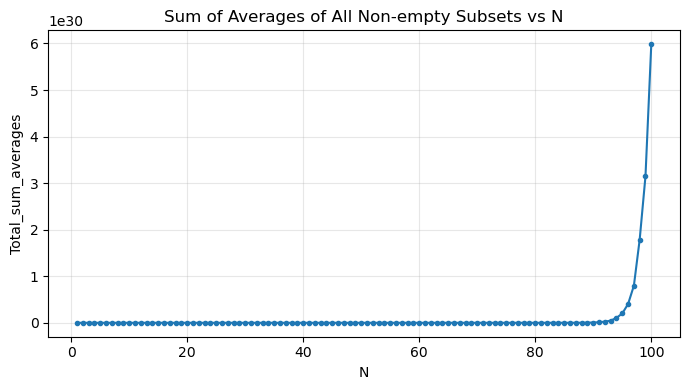

In [8]:
# 4. Dynamic programming (实则用组合恒等式实现 O(n) 时间)

import numpy as np
import matplotlib.pyplot as plt

# 4.1 随机整数数组
def Random_integer(N, low=0, high=10, rng=None):
    """
    生成长度为 N 的整数数组，元素均匀随机取自 [low, high]（含端点）。
    """
    if rng is None:
        rng = np.random.default_rng()
    # numpy 的整数上界是开区间，故 +1
    return rng.integers(low, high + 1, size=N)

# 4.2 所有子集平均值之和（高效闭式）
def Sum_averages(arr):
    """
    计算数组 arr 的所有非空子集的“平均值之和”。
    公式：Sum_averages = sum(arr) * (2^n - 1) / n
    其中 n = len(arr)
    """
    n = len(arr)
    if n == 0:
        return 0.0
    total = float(np.sum(arr))
    return total * (2**n - 1) / n

import itertools
import numpy as np

def Sum_averages_naive(arr):
    """
    朴素校验版：枚举所有非空子集，求平均后累加。
    只用于小 n 的自检，复杂度 O(2^n)。
    """
    arr = list(arr)
    n = len(arr)
    total = 0.0
    for k in range(1, n+1):
        for idx in itertools.combinations(range(n), k):
            total += sum(arr[i] for i in idx) / k
    return total

# For example：n=3 时验证闭式与朴素一致
_test = np.array([1, 2, 3])
assert abs(Sum_averages(_test) - Sum_averages_naive(_test)) < 1e-9
print("Self-check passed on [1,2,3].")

# 4.3 从 N=1 到 100，生成随机数组并计算 Total_sum_averages，绘图
rng = np.random.default_rng(2025)  # 固定随机种子便于复现实验
N_list = list(range(1, 101))
Total_sum_averages = []

for N in N_list:
    arr = Random_integer(N, low=0, high=10, rng=rng)
    Total_sum_averages.append(Sum_averages(arr))

# 简单查看前几项
print("First 5 N:", N_list[:5])
print("First 5 Total_sum_averages:", [round(x, 3) for x in Total_sum_averages[:5]])

# 绘图
plt.figure(figsize=(7,4))
plt.plot(N_list, Total_sum_averages, marker='o', ms=3)
plt.xlabel("N")
plt.ylabel("Total_sum_averages")
plt.title("Sum of Averages of All Non-empty Subsets vs N")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
